In [74]:
%reset -f

In [75]:
# import tensorflow as tf
# import tensorflow_decision_forests as tfdf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import expon, reciprocal, randint


from sklearn.svm import SVC 
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
#import xgboost as xgb
#from catboost import CatBoostClassifier
#from lightgbm import LGBMClassifier

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier, cv, DMatrix



# # Pour partir d'un environnement propre
# import sys
# for name in dir():
#     if not name.startswith('_'):
#         if not isinstance(globals()[name], type(sys)):
#             del globals()[name]
# del name


train_df = pd.read_csv("train.csv")
train_df_copy = train_df.copy()
test_df = pd.read_csv("test.csv")
test_df_copy = test_df.copy()
print("Full train dataset shape is {}".format(train_df.shape))

Full train dataset shape is (8693, 14)


# Toutes les modifications de nos données

## Ajout de nouvelles variables

In [76]:
def age_group(df):
    age_group  = []
    for i in df["Age"]:
        if i<=4:
            age_group.append("Age_0-4")
        elif (i>4 and i<=12):
            age_group.append("Age_05-12")
        elif (i>12 and i<=18):
            age_group.append("Age_13-18")
        elif (i>18 and i<=25):
            age_group.append("Age_19-25")
        elif (i>25 and i<=32):
            age_group.append("Age_26-32")
        elif (i>32 and i<=50):
            age_group.append("Age_33_50")
        elif (i>50):
            age_group.append("Age_50+")
        else:
            age_group.append(np.nan)
        
    df["Age Group"] = age_group

age_group(train_df)
age_group(test_df)


def passagerid_new_features(df):
    df["Group"] = df["PassengerId"].apply(lambda x: int(x.split("_")[0]))
    df["Member"] = df["PassengerId"].apply(lambda x: int(x.split("_")[1]))

    x = df.groupby("Group")["Member"].count()
    y = set(x[x>1].index)

    df["Travelling_Solo"] = df["Group"].apply(lambda x : x not in y)
    df["Group_size"] = 0

    for i in x.items():
        df.loc[df["Group"]==i[0], "Group_size"] = i[1]
    df["Group_size"] = df["Group_size"].astype(int)

passagerid_new_features(train_df)
passagerid_new_features(test_df)

def cabin_new_feature(df):
    df["Cabin"].fillna("np.nan/np.nan/np.nan", inplace=True)
    
    df["Cabin_Deck"] = df["Cabin"].apply(lambda x: x.split("/")[0])
    df["Cabin_Number"] = df["Cabin"].apply(lambda x: x.split("/")[1])
    df["Cabin_Side"] = df["Cabin"].apply(lambda x: x.split("/")[2])
    
    # Remplacer les valeurs de chaîne 'np.nan' par des valeurs NaN de numpy
    cols = ["Cabin_Deck", "Cabin_Number", "Cabin_Side"]
    df[cols] = df[cols].replace("np.nan", np.nan)
    
    # Remplir les valeurs manquantes dans les nouvelles caractéristiques créées
    df["Cabin_Deck"].fillna(df["Cabin_Deck"].mode()[0], inplace=True)
    df["Cabin_Side"].fillna(df["Cabin_Side"].mode()[0], inplace=True)
    df["Cabin_Number"] = pd.to_numeric(df["Cabin_Number"], errors='coerce')  # Conversion en numérique
    df["Cabin_Number"].fillna(df["Cabin_Number"].median(), inplace=True)

cabin_new_feature(train_df)
cabin_new_feature(test_df)

def cabin_regions(df):
    df["Cabin_Region1"] = (df["Cabin_Number"]<300)
    df["Cabin_Region2"] = (df["Cabin_Number"]>=300) & (df["Cabin_Number"]<600)
    df["Cabin_Region3"] = (df["Cabin_Number"]>=600) & (df["Cabin_Number"]<900)
    df["Cabin_Region4"] = (df["Cabin_Number"]>=900) & (df["Cabin_Number"]<1200)
    df["Cabin_Region5"] = (df["Cabin_Number"]>=1200) & (df["Cabin_Number"]<1500)
    df["Cabin_Region6"] = (df["Cabin_Number"]>=1500)

cabin_regions(train_df)
cabin_regions(test_df)

exp_cols = ["RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]
def new_exp_features(df):
    df["Total Expenditure"] = df[exp_cols].sum(axis=1)
    df["No Spending"] = (df["Total Expenditure"]==0)

new_exp_features(train_df)
new_exp_features(test_df)

def expenditure_category(df):
    expense_category = []   
    for i in df["Total Expenditure"]:
        if i==0:
            expense_category.append("No Expense")
        elif (i>0 and i<=716):
            expense_category.append("Low Expense")
        elif (i>716 and i<=1441):
            expense_category.append("Medium Expense")
        elif (i>1441):
            expense_category.append("High Expense")
    df["Expenditure Category"] = expense_category

expenditure_category(train_df)
expenditure_category(test_df)

train_df.drop(columns="VIP", inplace=True)
test_df.drop(columns="VIP", inplace=True)



## Remplissage des données manquantes

Cette partie est encore très naïve. IL faudra sûrement s'y attarder davantage dans le futur pour améliorer la précision de notre modèle.

In [77]:
# cat_cols = train_df.select_dtypes(include=["object","bool"]).columns.tolist()
# cat_cols.remove("Transported")
# num_cols = train_df.select_dtypes(include=["int","float"]).columns.tolist()

# def fill_missingno(df):
#     df[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(df[cat_cols])
#     df[num_cols] = SimpleImputer(strategy="median").fit_transform(df[num_cols])

# fill_missingno(train_df)
# fill_missingno(test_df)

Au lieu de remplir des données manquantes : Je teste de les supprimer :

In [78]:
## Manière naïve :

# # Suppression des lignes avec des données manquantes dans train_df
# train_df_cleaned = train_df.dropna()

# # Suppression des lignes avec des données manquantes dans test_df
# test_df_cleaned = test_df.dropna()

# # Affichage des dimensions avant et après pour comparer
# print("Dimensions originales de train_df:", train_df.shape)
# print("Dimensions après suppression des données manquantes pour train_df:", train_df_cleaned.shape)
# print("Dimensions originales de test_df:", test_df.shape)
# print("Dimensions après suppression des données manquantes pour test_df:", test_df_cleaned.shape)

# train_df = train_df_cleaned
# # test_df = test_df_cleaned


def custom_impute(df, group_col, cabin_cols):
    # Identifier les indices des voyageurs seuls
    solo_travelers = df[df['Travelling_Solo']].index
    
    # Boucle sur toutes les colonnes pour l'imputation
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:  # Pour les colonnes numériques
            # Imputez d'abord en utilisant les groupes pour les non-solos
            group_means = df.groupby(group_col)[col].transform('mean')
            df.loc[~df.index.isin(solo_travelers), col] = df.loc[~df.index.isin(solo_travelers), col].fillna(group_means)
            
            # Ensuite, utilisez les caractéristiques des cabines pour les solos
            cabin_means = df.groupby(cabin_cols)[col].transform('mean')
            df.loc[solo_travelers, col] = df.loc[solo_travelers, col].fillna(cabin_means)
            
        else:  # Pour les colonnes non numériques, utiliser le mode
            # Imputez d'abord en utilisant les groupes pour les non-solos
            group_modes = df.groupby(group_col)[col].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
            df.loc[~df.index.isin(solo_travelers), col] = df.loc[~df.index.isin(solo_travelers), col].fillna(group_modes)
            
            # Ensuite, utilisez les caractéristiques des cabines pour les solos
            cabin_modes = df.groupby(cabin_cols)[col].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
            df.loc[solo_travelers, col] = df.loc[solo_travelers, col].fillna(cabin_modes)
            
    # Fallback global pour les valeurs toujours manquantes après les groupes spécifiques
    global_means = df.mean(numeric_only=True)
    df.fillna(global_means, inplace=True)
    
    global_modes = df.mode().iloc[0]
    df.fillna(global_modes, inplace=True)

# Application de la fonction
custom_impute(train_df, 'Group', ['Cabin_Region1', 'Cabin_Deck', 'Cabin_Side'])
custom_impute(test_df, 'Group', ['Cabin_Region1', 'Cabin_Deck', 'Cabin_Side'])


ça fait une réduction d'environ 22% des données. C'est assez correct je trouve

## Suppression des variables maintenant inutiles

In [79]:
pass_df = test_df[["PassengerId"]]
cols = ["PassengerId","Cabin","Name","Cabin_Number"]

train_df.drop(columns =cols, inplace=True)
test_df.drop(columns=cols, inplace=True)


## Traitement final : Encodage One-Hot et Label Encoding

In [80]:
nominal_cat_cols_one_Hot = ["HomePlanet","Destination"]

train_df = pd.get_dummies(train_df, columns= nominal_cat_cols_one_Hot)
test_df = pd.get_dummies(test_df, columns = nominal_cat_cols_one_Hot)

ordinal_cat_cols_Label = ["CryoSleep","Travelling_Solo","Cabin_Deck","Cabin_Side","Cabin_Region1","Cabin_Region2",
                    "Cabin_Region3","Cabin_Region4","Cabin_Region5","Cabin_Region6","Age Group","No Spending",
                    "Expenditure Category"]     # J'ai enleve "VIP"

binary_cols = [col for col in train_df.columns if train_df[col].dropna().unique().size == 2]
new_binary_cols = [col for col in binary_cols if col not in ordinal_cat_cols_Label]

ordinal_cat_cols_Label.extend(new_binary_cols)
ordinal_cat_cols_Label.remove("Transported")

train_df[ordinal_cat_cols_Label] = train_df[ordinal_cat_cols_Label].apply(LabelEncoder().fit_transform)
test_df[ordinal_cat_cols_Label] = test_df[ordinal_cat_cols_Label].apply(LabelEncoder().fit_transform)

## Application d'une fonction logarithmique aux dépenses

In [81]:
cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','Total Expenditure']

for value in cols:
    train_df[value] = np.log(1+train_df[value])
    test_df[value]=np.log(1+test_df[value])

train_df.to_csv('train_travaille.csv', index=False)

## Pour commencer à travailler

Il est temps d'initialiser X et Y, et on fait à présent un partage des données entre X_train et X_test.
On fait également une normalisation des données : on aura donc le choix entre X_train et X_train_scaled pour construire notre modèle de prédiction.

In [82]:
Y = train_df["Transported"]
X = train_df.drop(columns=["Transported"])

X_scaled = StandardScaler().fit_transform(X)
test_df_scaled = StandardScaler().fit_transform(test_df)

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

X_train_scaled, X_test_scaled, Y_train_scaled, Y_test_scaled = train_test_split(X_scaled,Y,test_size=0.2,random_state=0)

## Suppression des variables créées inutiles

In [83]:
del binary_cols, cols, exp_cols, new_binary_cols, nominal_cat_cols_one_Hot, ordinal_cat_cols_Label, Y_train_scaled, Y_test_scaled

# Les modèles

C'est là qu'on peut enfin tester nos modèles

## Modèles de régressions logistiques

In [84]:

regression_model = LogisticRegression(random_state=0)
regression_model.fit(X_train_scaled, Y_train)

Y_pred = regression_model.predict(X_test_scaled)

print("Accuracy: ", accuracy_score(Y_test, Y_pred))

Accuracy:  0.7734330074755607


In [85]:
# Définir le modèle
model = LogisticRegression(random_state=0, solver='saga', max_iter=100)  # Augmentation de max_iter

# Définir la grille d'hyperparamètres à rechercher
param_grid = {
    'penalty': ['elasticnet'],  # Focus sur elasticnet
    'l1_ratio': np.linspace(0.7, 1, 300),  # Plus de valeurs pour l1_ratio
    'C': np.logspace(-4, 4, 20)  # Élargir la recherche pour C
}

# Configurer la recherche aléatoire avec validation croisée
random_search = RandomizedSearchCV(estimator=model, 
                                    param_distributions=param_grid, 
                                    n_iter=500,  # Nombre d'itérations de recherche
                                    cv=5,  # Validation croisée à 3 plis
                                    verbose=2, 
                                    random_state=42, 
                                    n_jobs=-1)

# Adapter le modèle de recherche aléatoire
random_search.fit(X_train_scaled, Y_train)

# Afficher les meilleurs paramètres et le meilleur score
print("Meilleurs paramètres :", random_search.best_params_)
print("Meilleur score :", random_search.best_score_)

l1_ratio_meilleur = random_search.best_params_['l1_ratio']
C_meilleur = random_search.best_params_['C']


# Prédire les valeurs de X_test_scaled en utilisant le meilleur modèle
Y_pred = random_search.best_estimator_.predict(X_test_scaled)

# Imprimer l'accuracy du modèle
print("Accuracy: ", accuracy_score(Y_test, Y_pred))


Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Meilleurs paramètres : {'penalty': 'elasticnet', 'l1_ratio': 0.7812709030100334, 'C': 0.03359818286283781}
Meilleur score : 0.7778270381538046
Accuracy:  0.7734330074755607


In [86]:
# Entraînement d'un modèle L1
model_L1 = LogisticRegression(random_state=0, solver='saga', penalty='l1', max_iter=5000)
model_L1.fit(X_train_scaled, Y_train)
Y_pred_L1 = model_L1.predict(X_test_scaled)
accuracy_L1 = accuracy_score(Y_test, Y_pred_L1)

# Entraînement d'un modèle L2
model_L2 = LogisticRegression(random_state=0, solver='saga', penalty='l2', max_iter=5000)
model_L2.fit(X_train_scaled, Y_train)
Y_pred_L2 = model_L2.predict(X_test_scaled)
accuracy_L2 = accuracy_score(Y_test, Y_pred_L2)

# Entraînement d'un modèle ElasticNet
model_elasticnet = LogisticRegression(random_state=0, solver='saga', penalty='elasticnet', l1_ratio=l1_ratio_meilleur, C=C_meilleur, max_iter=5000)
model_elasticnet.fit(X_train_scaled, Y_train)
Y_pred_elasticnet = model_elasticnet.predict(X_test_scaled)
accuracy_elasticnet = accuracy_score(Y_test, Y_pred_elasticnet)

print("Accuracy L1:", accuracy_L1)
print("Accuracy L2:", accuracy_L2)
print("Accuracy ElasticNet:", accuracy_elasticnet)



Accuracy L1: 0.7722829212190915
Accuracy L2: 0.7734330074755607
Accuracy ElasticNet: 0.7734330074755607


### Envoie des résultats

In [87]:
regression_model = LogisticRegression(random_state=0)
regression_model.fit(X_train_scaled, Y_train)

Y_test_pred = regression_model.predict(test_df_scaled)

#Créer le data frame de résultats
resultat_df = pd.DataFrame({
    'PassengerId':test_df_copy['PassengerId'],
    'Transported':Y_test_pred
})

resultat_df.to_csv('resultat.csv', index=False)

In [88]:
# Initialiser le modèle ElasticNet avec le l1_ratio et C trouvés
model_elasticnet = LogisticRegression(random_state=0, solver='saga', penalty='elasticnet', l1_ratio=l1_ratio_meilleur, C=C_meilleur, max_iter=5000)

# En supposant que X_train_scaled et Y_train sont déjà définis et correspondent à vos données d'entraînement
model_elasticnet.fit(X_train_scaled, Y_train)

# Prédire les valeurs sur l'ensemble de test prétraité
Y_test_pred = model_elasticnet.predict(test_df_scaled)

# Créer le DataFrame de résultats
resultat_df = pd.DataFrame({
    'PassengerId': test_df_copy['PassengerId'],
    'Transported': Y_test_pred
})

# Sauvegarder le DataFrame dans un fichier CSV
resultat_df.to_csv('resultat_elasticnet.csv', index=False)

## Adaboosting Naïf

In [89]:
# Initialisation du modèle AdaBoost avec un stump comme estimateur de base
ada_clf = AdaBoostClassifier(n_estimators=100, random_state=0)

# Entraînement du modèle avec les données normalisées
ada_clf.fit(X_train_scaled, Y_train)

# Prédiction sur l'ensemble de test
Y_pred = ada_clf.predict(X_test_scaled)

# Calcul de la précision du modèle
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Précision du modèle AdaBoost : {accuracy}")


Précision du modèle AdaBoost : 0.7906843013225991


### Avec de la validation croisée

In [90]:
# Initialisation du modèle AdaBoost
ada_clf = AdaBoostClassifier(n_estimators=100, random_state=0)

# Application de la validation croisée k-fold
# Remarque : Utilisez X_scaled et Y au lieu de X_train_scaled et Y_train_scaled
# pour que la validation croisée utilise l'ensemble du jeu de données
scores = cross_val_score(ada_clf, X_scaled, Y, cv=5) # cv=5 pour un 5-fold

# Affichage des scores de précision pour chaque fold
print("Précision pour chaque fold :", scores)

# Calcul de la précision moyenne sur tous les folds
print("Précision moyenne :", scores.mean())

Précision pour chaque fold : [0.49856239 0.66877516 0.71477861 0.77330265 0.4976985 ]
Précision moyenne : 0.6306234618919779


In [91]:
from sklearn.model_selection import GridSearchCV

# Paramètres à tester
param_grid = {'n_estimators': [50, 100, 200, 300]}

# Initialisation de la recherche sur grille
grid_search = GridSearchCV(AdaBoostClassifier(random_state=0), param_grid, cv=5, scoring='accuracy')

# Entraînement et recherche des meilleurs paramètres
grid_search.fit(X_train_scaled, Y_train)

# Affichage des meilleurs paramètres et de la meilleure précision obtenue
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleure précision :", grid_search.best_score_)

# Utilisation des meilleurs paramètres pour faire des prédictions sur l'ensemble de test
Y_pred = grid_search.predict(X_test_scaled)
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Précision sur l'ensemble de test avec les meilleurs paramètres : {accuracy}")


Meilleurs paramètres : {'n_estimators': 300}
Meilleure précision : 0.7926390102870974
Précision sur l'ensemble de test avec les meilleurs paramètres : 0.7918343875790684


In [92]:
# Assurez-vous que test_df_scaled est bien préparé et prêt pour la prédiction
# et que test_df_copy contient la colonne 'PassengerId' correspondante.

# Initialisation du modèle AdaBoost avec n_estimators=200
ada_boost_model = AdaBoostClassifier(n_estimators=300, random_state=0)

# Entraînement du modèle AdaBoost avec les données d'entraînement normalisées
ada_boost_model.fit(X_train_scaled, Y_train)  # Assurez-vous que Y_train_scaled est votre variable cible

# Prédiction sur l'ensemble de test normalisé
Y_test_pred = ada_boost_model.predict(test_df_scaled)

# Créer le dataframe de résultats
resultat_df = pd.DataFrame({
    'PassengerId': test_df_copy['PassengerId'],  # Assurez-vous que test_df_copy a été défini précédemment
    'Transported': Y_test_pred.astype(bool)  # Conversion des prédictions en booléen si nécessaire
})

# Enregistrement du dataframe dans un fichier CSV
resultat_df.to_csv('resultat_adaboost.csv', index=False)

## SVM

In [93]:
# Initialisation du modèle SVM avec des paramètres par défaut
svm_model = SVC(random_state=0)

# Entraînement du modèle SVM avec l'ensemble d'entraînement mis à l'échelle
svm_model.fit(X_train_scaled, Y_train)

# Prédiction sur l'ensemble de test
Y_test_pred = svm_model.predict(X_test_scaled)

# Calcul et affichage de la précision du modèle
accuracy = accuracy_score(Y_test, Y_test_pred)
print(f"Précision du modèle SVM : {accuracy}")

Précision du modèle SVM : 0.7929844738355377


In [94]:
from scipy.stats import expon, reciprocal

# # Définir l'espace des hyperparamètres à explorer
# param_distributions = {
#     'C': reciprocal(0.001, 10),
#     'kernel': ['linear', 'poly', 'sigmoid', 'rbf'],  # Vous pourriez vouloir tester d'autres noyaux également
# }

param_distributions = {
    'C': reciprocal(0.001, 20),
    'kernel': ['rbf'],
    'gamma': reciprocal(0.001, 0.1)  # Plage suggérée pour l'exploration de gamma
}

# Initialisation du modèle SVM
svm_model = SVC(random_state=0)

# Création de l'instance RandomizedSearchCV
random_search = RandomizedSearchCV(
    svm_model, param_distributions, 
    n_iter=100,  # Limite le nombre d'itérations pour respecter le temps d'exécution
    cv=5,  # Réduit le nombre de folds de CV pour accélérer l'exécution
    verbose=1,  # Affiche des informations sur l'exécution
    random_state=0,  # Pour la reproductibilité
    n_jobs=-1  # Utilise tous les cœurs disponibles
)

# Exécution de la recherche aléatoire
import time
start_time = time.time()

random_search.fit(X_train_scaled, Y_train)

gamma_meilleur = random_search.best_params_['gamma']
C_meilleur = random_search.best_params_['C']

end_time = time.time()
print(f"Optimisation terminée en {end_time - start_time} secondes")
print(f"Meilleurs paramètres : {random_search.best_params_}")
print(f"Meilleure score : {random_search.best_score_}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Optimisation terminée en 124.42048978805542 secondes
Meilleurs paramètres : {'C': 15.840958221435734, 'gamma': 0.008655704137361813, 'kernel': 'rbf'}
Meilleure score : 0.7946510196587517


In [95]:
# Initialisation du modèle SVM
SVM_model = SVC(C= C_meilleur, gamma=gamma_meilleur, kernel='rbf')

# Entraînement du modèle SVM avec les données d'entraînement normalisées
SVM_model.fit(X_train_scaled, Y_train)

# Prédiction sur l'ensemble de test normalisé
Y_test_pred = SVM_model.predict(test_df_scaled)

# Créer le dataframe de résultats
resultat_df = pd.DataFrame({
    'PassengerId': test_df_copy['PassengerId'],
    'Transported': Y_test_pred.astype(bool)  # Conversion des prédictions en booléen si nécessaire
})

# Enregistrement du dataframe dans un fichier CSV
resultat_df.to_csv('resultat_SVM.csv', index=False)

## Arbres de décision

In [118]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.stats import randint


# Définition de la distribution des paramètres pour RandomizedSearchCV
param_distributions = {
    'max_depth': randint(1, 10),  # Tester des profondeurs d'arbres de 1 à 10
    'min_samples_split': randint(2, 20),  # Tester des valeurs pour min_samples_split de 2 à 20
    'min_samples_leaf': randint(1, 20),  # Tester des valeurs pour min_samples_leaf de 1 à 20
}

# Appliquer RandomizedSearchCV pour les critères de Gini et d'Entropy
# Pour Gini
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=0)
random_search_gini = RandomizedSearchCV(clf_gini, param_distributions, n_iter=100, cv=5, random_state=0, scoring='accuracy')
random_search_gini.fit(X_train_scaled, Y_train)

# Pour Entropy
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=0)
random_search_entropy = RandomizedSearchCV(clf_entropy, param_distributions, n_iter=100, cv=5, random_state=0, scoring='accuracy')
random_search_entropy.fit(X_train_scaled, Y_train)

# Meilleurs paramètres et score
best_params_gini = random_search_gini.best_params_
best_score_gini = random_search_gini.best_score_

best_params_entropy = random_search_entropy.best_params_
best_score_entropy = random_search_entropy.best_score_

best_params_gini, best_score_gini, best_params_entropy, best_score_entropy


({'max_depth': 7, 'min_samples_leaf': 9, 'min_samples_split': 19},
 0.7886110608278296,
 {'max_depth': 9, 'min_samples_leaf': 16, 'min_samples_split': 11},
 0.7881784751925276)

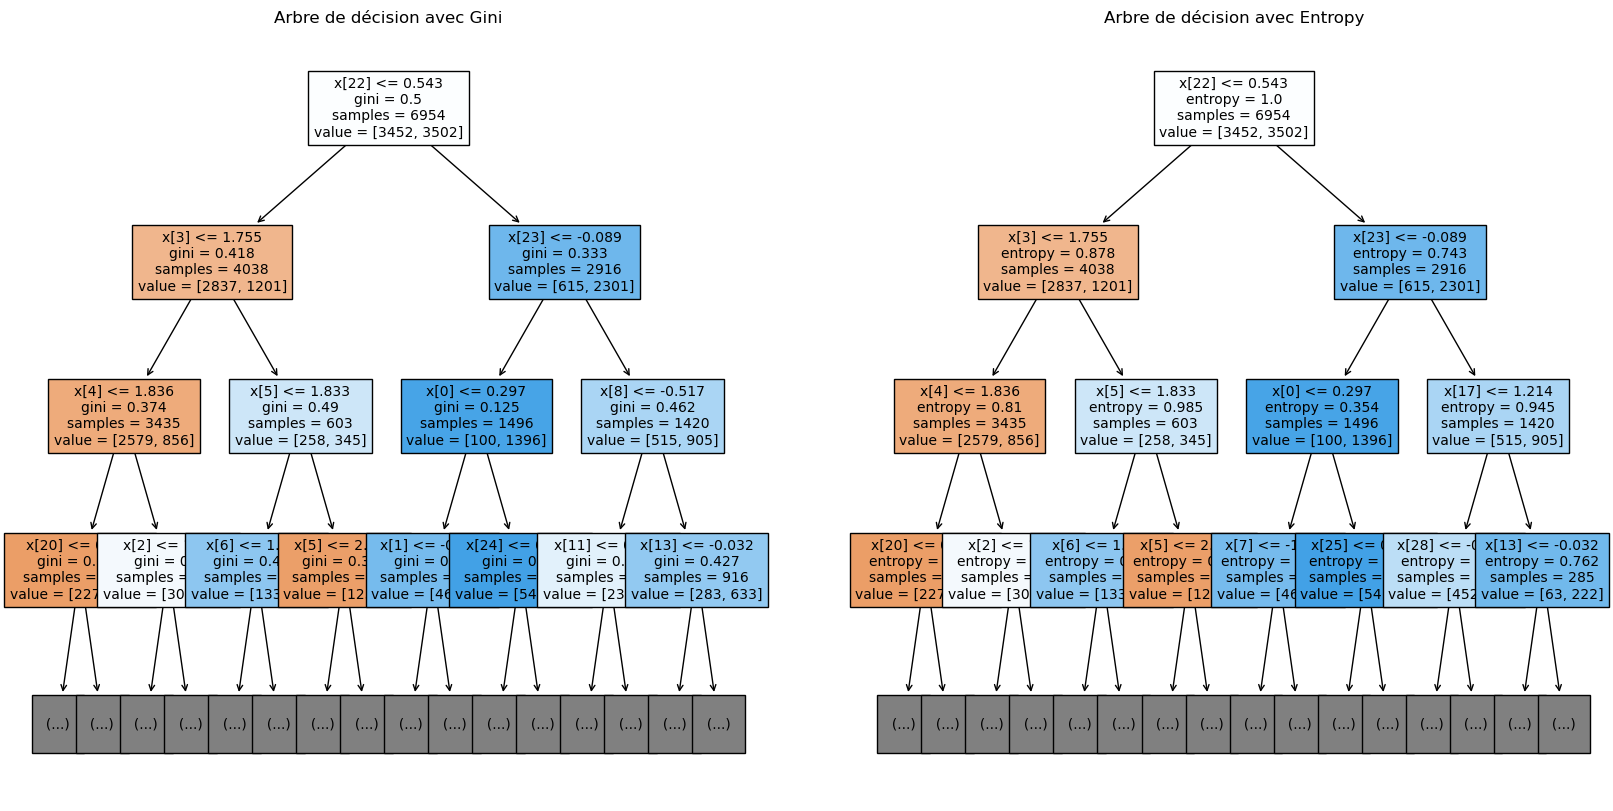

C:\Users\mkoud\AppData\Local\Temp\ipykernel_472\675065586.py:41: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_pca[idx_true & ~idx_pred, 0], X_pca[idx_true & ~idx_pred, 1],


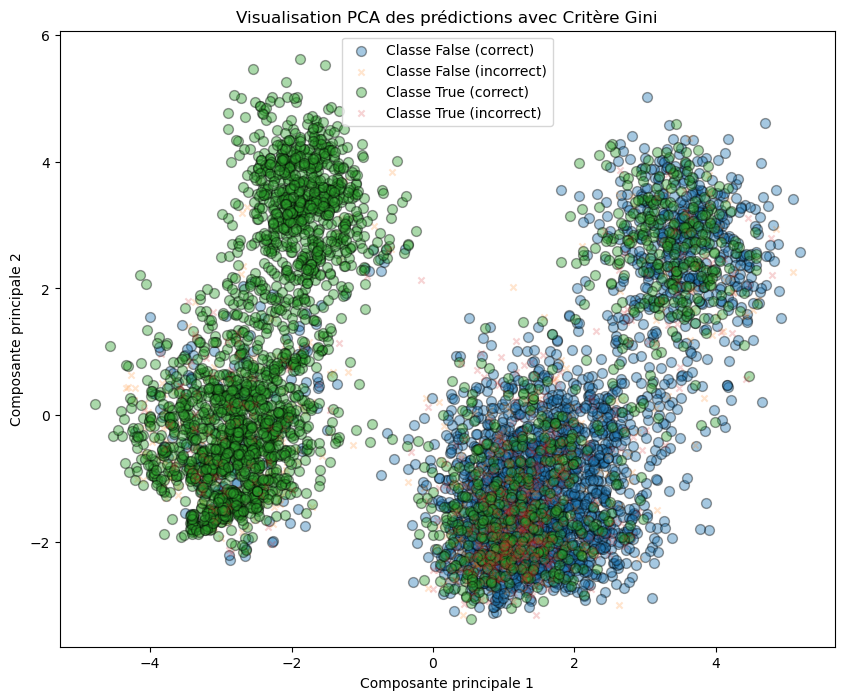

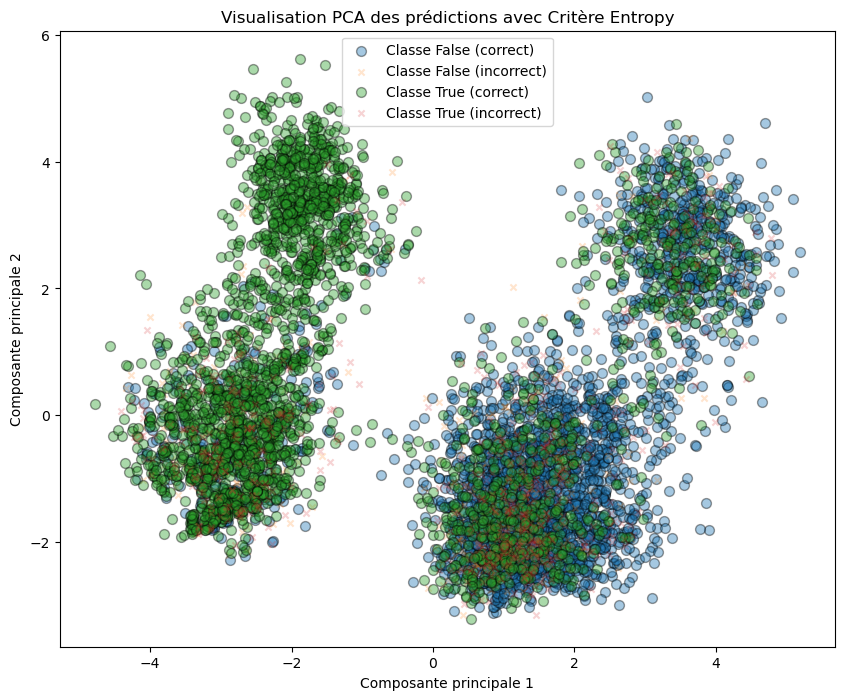

In [122]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Supposition : X_train_scaled, Y_train, best_params_gini, et best_params_entropy sont définis

# Entraînement des modèles avec les meilleurs paramètres
clf_best_gini = DecisionTreeClassifier(criterion='gini', random_state=0, **best_params_gini)
clf_best_gini.fit(X_train_scaled, Y_train)

clf_best_entropy = DecisionTreeClassifier(criterion='entropy', random_state=0, **best_params_entropy)
clf_best_entropy.fit(X_train_scaled, Y_train)

# Tracé des arbres de décision
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plot_tree(clf_best_gini, filled=True, max_depth=3, fontsize=10)
plt.title('Arbre de décision avec Gini')

plt.subplot(1, 2, 2)
plot_tree(clf_best_entropy, filled=True, max_depth=3, fontsize=10)
plt.title('Arbre de décision avec Entropy')

plt.show()

# PCA pour visualisation en 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

def plot_pca_results(X_pca, Y_true, Y_pred, title):
    plt.figure(figsize=(10, 8))
    for cls in np.unique(Y_true):
        idx_true = (Y_true == cls)
        idx_pred = (Y_pred == cls)
        # Points correctement classifiés
        plt.scatter(X_pca[idx_true & idx_pred, 0], X_pca[idx_true & idx_pred, 1], 
                    label=f'Classe {cls} (correct)', edgecolor='k', s=50, alpha=0.4)
        # Points incorrectement classifiés, plus discrets
        plt.scatter(X_pca[idx_true & ~idx_pred, 0], X_pca[idx_true & ~idx_pred, 1], 
                    label=f'Classe {cls} (incorrect)', edgecolor='k', s=20, marker='x', alpha=0.2)
    
    plt.title(f'Visualisation PCA des prédictions avec {title}')
    plt.xlabel('Composante principale 1')
    plt.ylabel('Composante principale 2')
    plt.legend()
    plt.show()


# Prédictions sur l'ensemble d'entraînement
Y_train_pred_gini = clf_best_gini.predict(X_train_scaled)
Y_train_pred_entropy = clf_best_entropy.predict(X_train_scaled)

# Tracer les résultats de PCA pour Gini
plot_pca_results(X_train_pca, Y_train, Y_train_pred_gini, 'Critère Gini')

# Tracer les résultats de PCA pour Entropy
plot_pca_results(X_train_pca, Y_train, Y_train_pred_entropy, 'Critère Entropy')


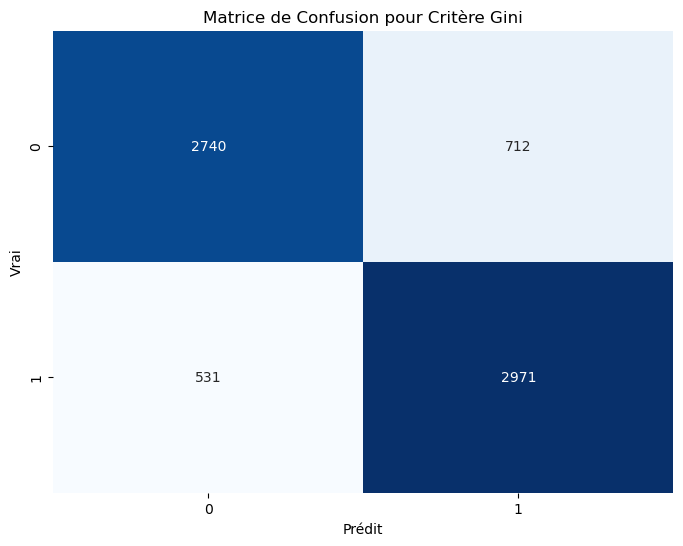

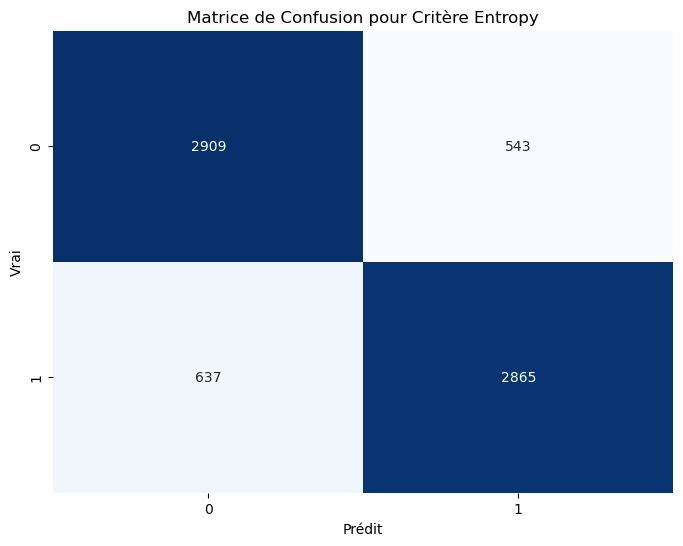

In [123]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# Calcul des matrices de confusion pour les deux critères
conf_matrix_gini = confusion_matrix(Y_train, Y_train_pred_gini)
conf_matrix_entropy = confusion_matrix(Y_train, Y_train_pred_entropy)

# Fonction pour afficher la matrice de confusion
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False)
    plt.title(f'Matrice de Confusion {title}')
    plt.xlabel('Prédit')
    plt.ylabel('Vrai')
    plt.show()

# Affichage de la matrice de confusion pour Gini
plot_confusion_matrix(conf_matrix_gini, 'pour Critère Gini')

# Affichage de la matrice de confusion pour Entropy
plot_confusion_matrix(conf_matrix_entropy, 'pour Critère Entropy')


encore un test

In [ ]:
# Initialisation du modèle DecisionTreeClassifier
Arbre_model = DecisionTreeClassifier(max_depth=7, min_samples_leaf=min_leaf_best, min_samples_split=min_split_best)

# Entraînement du modèle DecisionTreeClassifier avec les données d'entraînement normalisées
Arbre_model.fit(X_train_scaled, Y_train)

# Prédiction sur l'ensemble de test normalisé
Y_test_pred = Arbre_model.predict(test_df_scaled)

# Créer le dataframe de résultats
resultat_df = pd.DataFrame({
    'PassengerId': test_df_copy['PassengerId'],
    'Transported': Y_test_pred.astype(bool)  # Conversion des prédictions en booléen si nécessaire
})

# Enregistrement du dataframe dans un fichier CSV
resultat_df.to_csv('resultat_arbres.csv', index=False)

## Adaboost avec des bons arbres

In [226]:

# Création de l'arbre de décision avec les meilleurs hyperparamètres trouvés
best_dt = DecisionTreeClassifier(max_depth=prodondeur_best, min_samples_split=min_split_best, min_samples_leaf=min_leaf_best, random_state=0)

# Initialisation du modèle AdaBoost avec l'arbre de décision comme estimateur de base
ada_boost_model = AdaBoostClassifier(estimator=best_dt, n_estimators=1000, random_state=0)

# Entraînement du modèle AdaBoost
ada_boost_model.fit(X_train, Y_train)

# Prédiction sur l'ensemble de test
Y_test_pred = ada_boost_model.predict(X_test)

# Évaluation du modèle
accuracy = accuracy_score(Y_test, Y_test_pred)
print(f"Précision de l'AdaBoost avec un arbre de décision comme estimateur de base : {accuracy}")


Précision de l'AdaBoost avec un arbre de décision comme estimateur de base : 0.7964347326049454


In [227]:

# Initialisation du modèle AdaBoost avec n_estimators=200
ada_boost_model = AdaBoostClassifier(estimator=best_dt, n_estimators=1000, random_state=0)

# Entraînement du modèle AdaBoost avec les données d'entraînement normalisées
ada_boost_model.fit(X_train_scaled, Y_train)  # Assurez-vous que Y_train_scaled est votre variable cible

# Prédiction sur l'ensemble de test normalisé
Y_test_pred = ada_boost_model.predict(test_df_scaled)

# Créer le dataframe de résultats
resultat_df = pd.DataFrame({
    'PassengerId': test_df_copy['PassengerId'],  # Assurez-vous que test_df_copy a été défini précédemment
    'Transported': Y_test_pred.astype(bool)  # Conversion des prédictions en booléen si nécessaire
})

# Enregistrement du dataframe dans un fichier CSV
resultat_df.to_csv('resultat_adaboost.csv', index=False)

## XGBoost

In [25]:
from xgboost import XGBClassifier, cv, DMatrix
import pandas as pd

# Convertir les données en DMatrix - le format optimisé de données utilisé par XGBoost
dtrain = DMatrix(X_train_scaled, label=Y_train)

# Configuration des paramètres de XGBoost
params = {
    'max_depth': prodondeur_best,  # Utiliser les valeurs optimales trouvées précédemment
    'learning_rate': 0.1,
    'n_estimators': 1000,
    'objective': 'binary:logistic',  # Objectif pour la classification binaire
    'eval_metric': 'logloss',  # Utiliser logloss pour la classification binaire
    'use_label_encoder': False,
    'seed': 0
}

# Exécution de la validation croisée
cv_results = cv(dtrain=dtrain, params=params, nfold=5,
                num_boost_round=1000,  # Nombre de tours de boosting
                early_stopping_rounds=50,  # Arrêt précoce pour prévenir le surapprentissage
                metrics={'logloss'}, seed=0)

# Affichage des résultats de la validation croisée
print(cv_results)

# Affichage de la meilleure logloss moyenne
print(f"Meilleure logloss moyenne lors de la validation croisée: {cv_results['test-logloss-mean'].min()}")


c:\Users\colin\anaconda3\envs\Alaska\Lib\site-packages\xgboost\core.py:160: UserWarning: [02:25:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "n_estimators", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


    train-logloss-mean  train-logloss-std  test-logloss-mean  test-logloss-std
0             0.645374           0.000616           0.650200          0.001198
1             0.605381           0.000747           0.614765          0.002338
2             0.571839           0.000938           0.585048          0.003232
3             0.543208           0.001084           0.560699          0.004096
4             0.518444           0.001197           0.539830          0.004813
..                 ...                ...                ...               ...
71            0.257271           0.004253           0.395860          0.011216
72            0.255625           0.003699           0.395403          0.011451
73            0.255074           0.003696           0.395342          0.011474
74            0.254452           0.003851           0.395174          0.011294
75            0.253658           0.004126           0.395145          0.011322

[76 rows x 4 columns]
Meilleure logloss moyenne lor

In [26]:
# Si la performance est satisfaisante, entraînez le modèle final avec les paramètres choisis
xgb_model_final = XGBClassifier(**params)
xgb_model_final.fit(X_train_scaled, Y_train)

# Prédiction sur l'ensemble de test normalisé
Y_test_pred = xgb_model_final.predict(test_df_scaled)

# Création du dataframe de résultats
resultat_df = pd.DataFrame({
    'PassengerId': test_df_copy['PassengerId'],
    'Transported': Y_test_pred.astype(bool)
})

# Enregistrement dans un fichier CSV
resultat_df.to_csv('resultat_xgboost.csv', index=False)